### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import the salary dataset

In [3]:
df=pd.read_csv(r"C:\Users\PC\Downloads\Salary_dataset.csv", index_col=0)
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [5]:
df.shape

(30, 2)

### EDA

In [5]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [5]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

### Correlation analysis

<Axes: xlabel='YearsExperience', ylabel='Salary'>

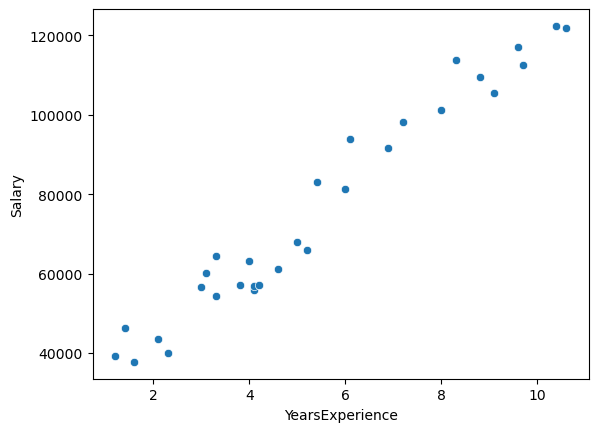

In [6]:
# check whethere columns are Linearly related to each other or not
# Linear regression only works on data which is linearly related to each other.
sns.scatterplot(x= df['YearsExperience'],y =df['Salary'])

<Axes: >

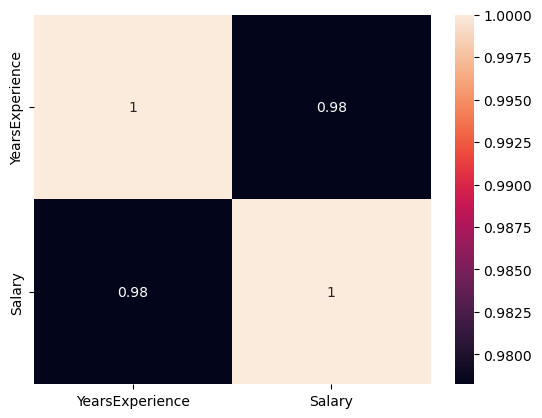

In [7]:
sns.heatmap(df.corr(), annot=True)

### Model

In [8]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [9]:
df['YearsExperience']

0      1.2
1      1.4
2      1.6
3      2.1
4      2.3
5      3.0
6      3.1
7      3.3
8      3.3
9      3.8
10     4.0
11     4.1
12     4.1
13     4.2
14     4.6
15     5.0
16     5.2
17     5.4
18     6.0
19     6.1
20     6.9
21     7.2
22     8.0
23     8.3
24     8.8
25     9.1
26     9.6
27     9.7
28    10.4
29    10.6
Name: YearsExperience, dtype: float64

In [10]:
#Defining x & y
x=df[['YearsExperience']]   # x column must be in 2D format so use double square brackets to convert it into 2D
y=df['Salary']   # y column must be 1D 

In [11]:
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [12]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

### Model Training

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lr=LinearRegression()
lr

LinearRegression()

In [19]:
lr.fit(x,y)     # Training model(Calculating m & c value with fit function)

LinearRegression()

In [14]:
lr.coef_      #Slope of Line

array([9449.96232146])

In [15]:
lr.intercept_       #Intercept of Line

np.float64(24848.203966523222)

In [16]:
# Getting prediction on new data
m=9449
c=24848
q=1
m*x+c

,YearsExperience
0,36186.8
1,38076.6
2,39966.4
3,44690.9
4,46580.7
5,53195.0
6,54139.9
7,56029.7
8,56029.7
9,60754.2


### Prediting for Actual values

In [17]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [18]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [19]:
#get predicted values on real years exp column for evaluation purpose.
ypred=lr.predict(x)
ypred

array([ 36188.15875227,  38078.15121656,  39968.14368085,  44693.12484158,
        46583.11730587,  53198.09093089,  54143.08716303,  56033.07962732,
        56033.07962732,  60758.06078805,  62648.05325234,  63593.04948449,
        63593.04948449,  64538.04571663,  68318.03064522,  72098.0155738 ,
        73988.00803809,  75878.00050238,  81547.97789525,  82492.9741274 ,
        90052.94398456,  92887.932681  , 100447.90253816, 103282.8912346 ,
       108007.87239533, 110842.86109176, 115567.84225249, 116512.83848464,
       123127.81210966, 125017.80457395])

### Model Evalution

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
mse= mean_squared_error(y,ypred)
mse

31270951.722280968

In [22]:
rmse= np.sqrt(mse)   #RMSE calculation.
rmse

np.float64(5592.043608760662)

In [23]:
r2_score(y,ypred)

0.9569566641435086

### Visualizing the model

In [25]:
df.head(4)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0


In [26]:
df['Predicated_Salary'] = ypred   #Adding new column of predicted values
df.head(7)

,YearsExperience,Salary,Predicated_Salary
0,1.2,39344.0,36188.158752
1,1.4,46206.0,38078.151217
2,1.6,37732.0,39968.143681
3,2.1,43526.0,44693.124842
4,2.3,39892.0,46583.117306
5,3.0,56643.0,53198.090931
6,3.1,60151.0,54143.087163


<Axes: xlabel='YearsExperience', ylabel='Salary'>

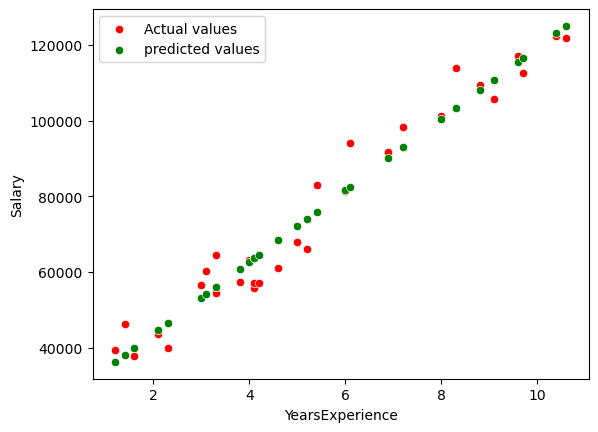

In [28]:
sns.scatterplot(x=df['YearsExperience'],y =df['Salary'],color ='red',label='Actual values')
sns.scatterplot(x=df['YearsExperience'],y =ypred,color ='green',label='predicted values')

<Axes: xlabel='YearsExperience', ylabel='Salary'>

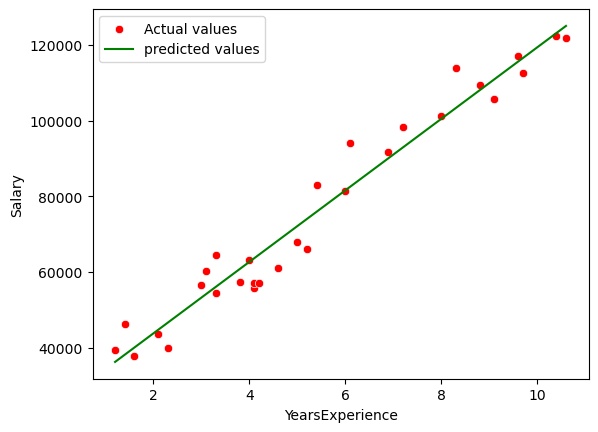

In [29]:
sns.scatterplot(x=df['YearsExperience'],y =df['Salary'],color ='red',label='Actual values')
sns.lineplot(x=df['YearsExperience'],y =ypred,color ='green',label='predicted values')

### Predicated new values

In [30]:
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [31]:
test=pd.DataFrame({'YearsExperience':[1,15,12.8,23,18]})
test

,YearsExperience
0,1.0
1,15.0
2,12.8
3,23.0
4,18.0


In [32]:
lr.predict(test)

array([ 34298.16628798, 166597.63878835, 145807.72168115, 242197.33735999,
       194947.52575271])